# EDA - Dataset TACO (Trash Annotations in Context)

Análisis exploratorio del dataset TACO antes de entrenar el modelo de segmentación de residuos.

Adaptado del EDA genérico de la materia (`EDA_preproc_dataset.ipynb`), pero leyendo
las anotaciones COCO en vez de una estructura de carpetas por clase, ya que TACO
distribuye sus anotaciones en un único `annotations.json`.


In [1]:
import json
import os
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

TACO_DIR = Path("../data/TACO/data")
ANNOTATIONS_PATH = TACO_DIR / "annotations.json"

with open(ANNOTATIONS_PATH) as f:
    coco = json.load(f)

print("Imágenes:", len(coco["images"]))
print("Anotaciones:", len(coco["annotations"]))
print("Categorías originales:", len(coco["categories"]))


Imágenes: 1500
Anotaciones: 4784
Categorías originales: 60


## 1. Cantidad de instancias por categoría original (60 clases finas de TACO)

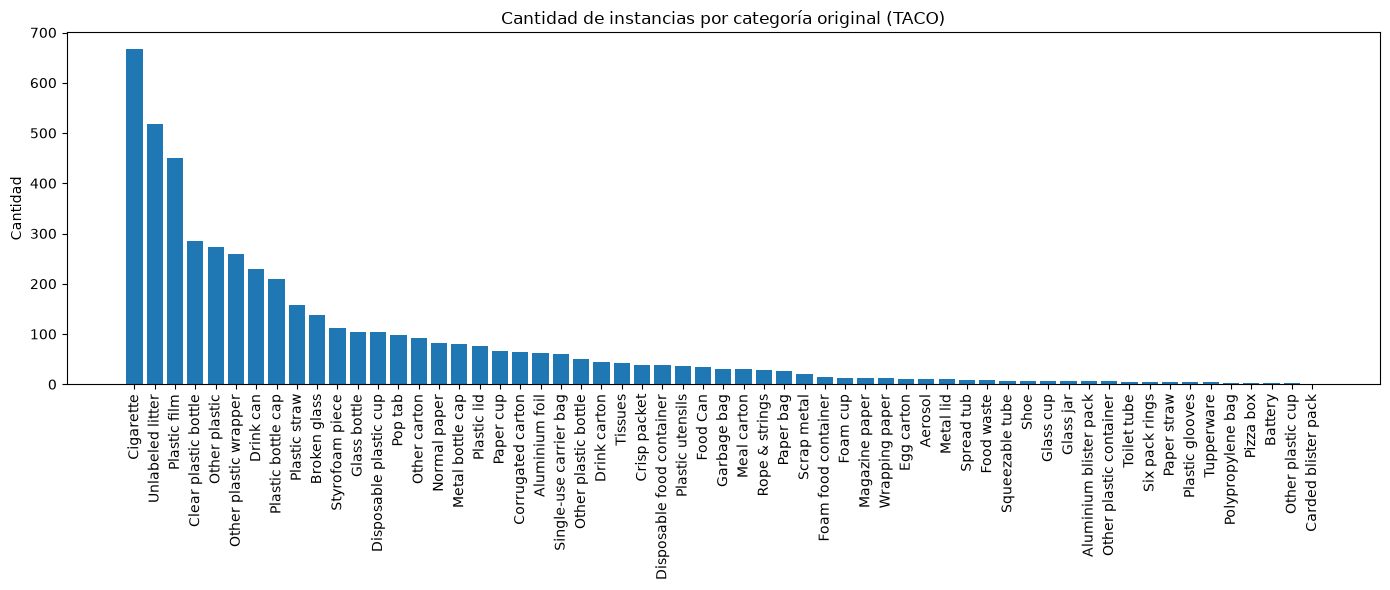

In [2]:
category_names = {c["id"]: c["name"] for c in coco["categories"]}
category_super = {c["id"]: c.get("supercategory", "") for c in coco["categories"]}

instance_counts = Counter(ann["category_id"] for ann in coco["annotations"])

sorted_counts = sorted(instance_counts.items(), key=lambda x: -x[1])
labels = [category_names[cid] for cid, _ in sorted_counts]
values = [v for _, v in sorted_counts]

plt.figure(figsize=(14, 6))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.title("Cantidad de instancias por categoría original (TACO)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()


## 2. Cantidad de instancias agrupadas por clase macro del proyecto

Usamos el mismo mapeo `SUPERCATEGORY_TO_MACRO` que se usa en `data/prepare_dataset.py`,
para verificar el balance de clases ANTES de entrenar.


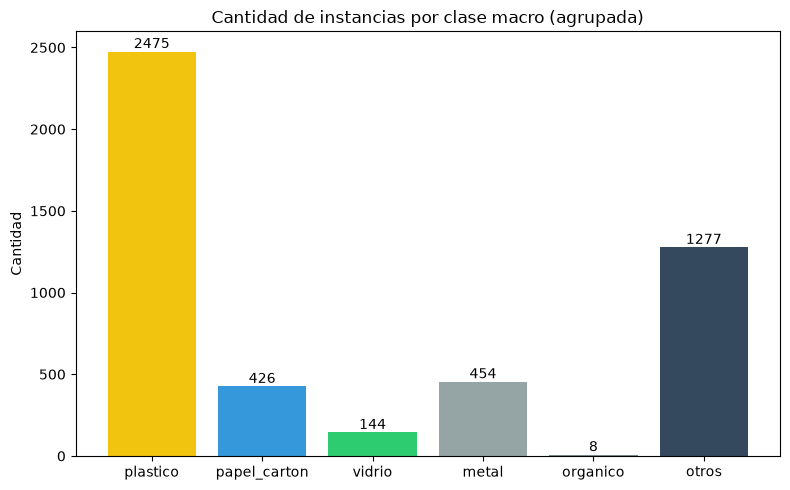


Categorías finas sin supercategoría mapeada (cayeron en 'otros'):
  Plastic utensils: 37
  Rope & strings: 29
  Plastic glooves: 4


In [3]:
import sys
sys.path.append("../data")
from prepare_dataset import SUPERCATEGORY_TO_MACRO, MACRO_CLASSES

macro_counts = Counter()
sin_mapeo = Counter()

for ann in coco["annotations"]:
    cid = ann["category_id"]
    super_cat = category_super[cid]
    macro = SUPERCATEGORY_TO_MACRO.get(super_cat)
    if macro is None:
        macro = "otros"
        sin_mapeo[category_names[cid]] += 1
    macro_counts[macro] += 1

plt.figure(figsize=(8, 5))
bars = plt.bar(MACRO_CLASSES, [macro_counts.get(c, 0) for c in MACRO_CLASSES],
               color=["#f1c40f", "#3498db", "#2ecc71", "#95a5a6", "#7f8c8d", "#34495e"])
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 1, str(int(y)), ha="center", va="bottom")
plt.title("Cantidad de instancias por clase macro (agrupada)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

print("\nCategorías finas sin supercategoría mapeada (cayeron en 'otros'):")
for name, count in sin_mapeo.most_common(10):
    print(f"  {name}: {count}")


## 3. Distribución de resoluciones y relación de aspecto

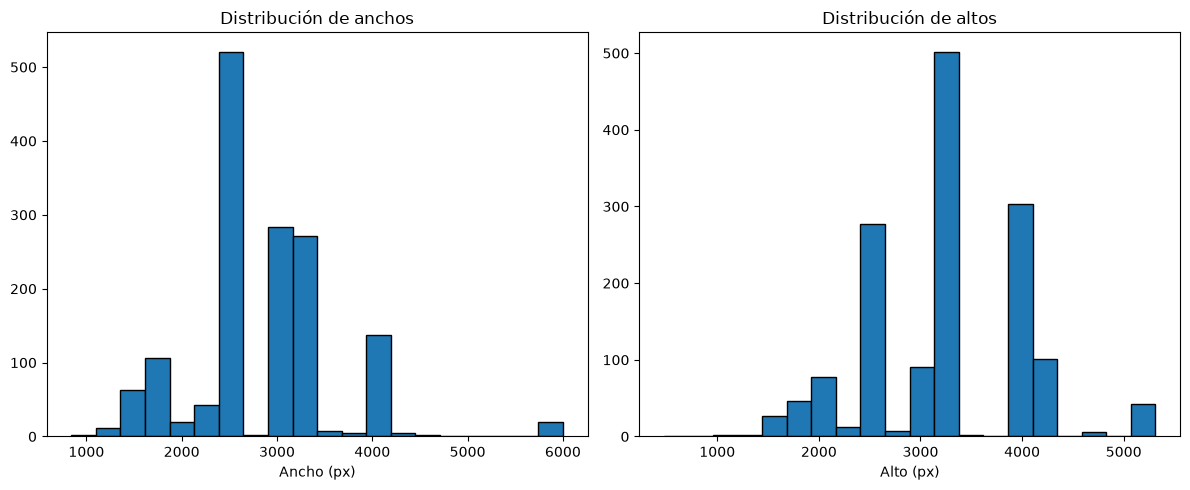

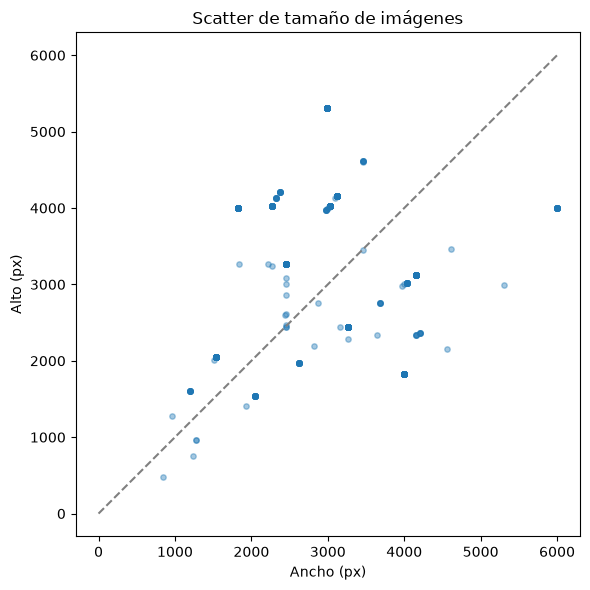

In [4]:
widths = [img["width"] for img in coco["images"]]
heights = [img["height"] for img in coco["images"]]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(widths, bins=20, edgecolor="black")
plt.title("Distribución de anchos")
plt.xlabel("Ancho (px)")

plt.subplot(1, 2, 2)
plt.hist(heights, bins=20, edgecolor="black")
plt.title("Distribución de altos")
plt.xlabel("Alto (px)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, alpha=0.4, s=15)
max_val = max(max(widths), max(heights))
plt.plot([0, max_val], [0, max_val], linestyle="--", color="gray")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.title("Scatter de tamaño de imágenes")
plt.tight_layout()
plt.show()


## 4. Cantidad de objetos por imagen (relevante para el caso de múltiples residuos)

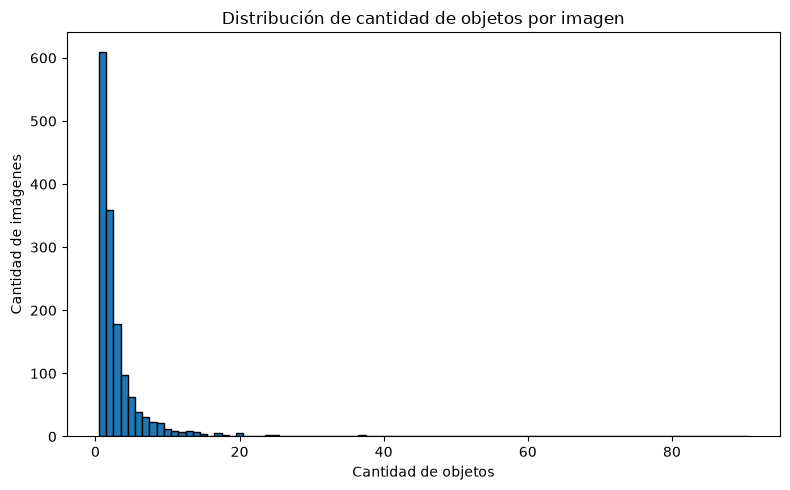

Promedio de objetos por imagen: 3.19
Máximo de objetos en una sola imagen: 90


In [5]:
objects_per_image = Counter(ann["image_id"] for ann in coco["annotations"])
counts = list(objects_per_image.values())

plt.figure(figsize=(8, 5))
plt.hist(counts, bins=range(1, max(counts) + 2), edgecolor="black", align="left")
plt.title("Distribución de cantidad de objetos por imagen")
plt.xlabel("Cantidad de objetos")
plt.ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.show()

print(f"Promedio de objetos por imagen: {np.mean(counts):.2f}")
print(f"Máximo de objetos en una sola imagen: {max(counts)}")


## 5. Visualización de muestras con sus máscaras originales

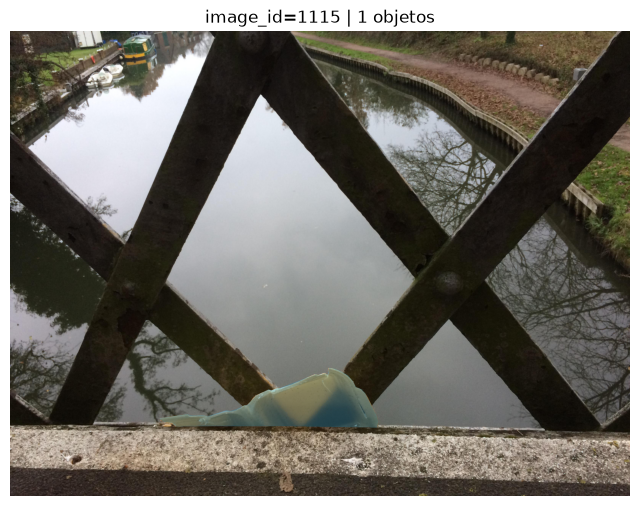

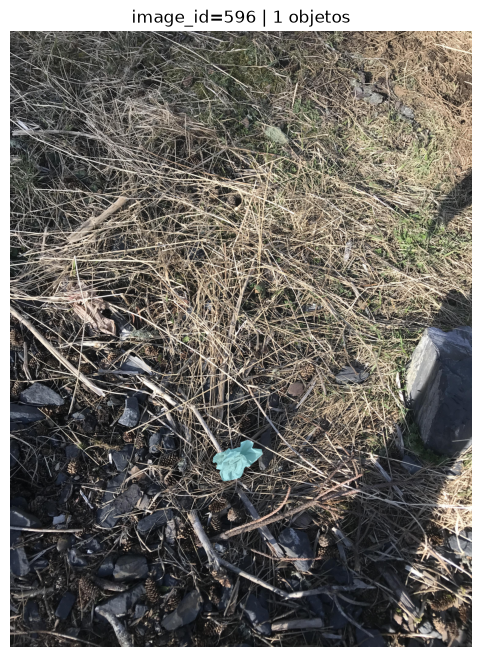

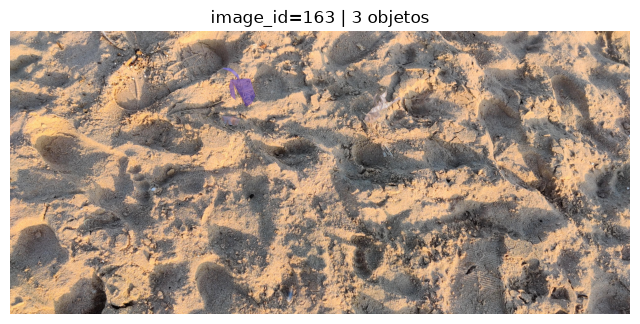

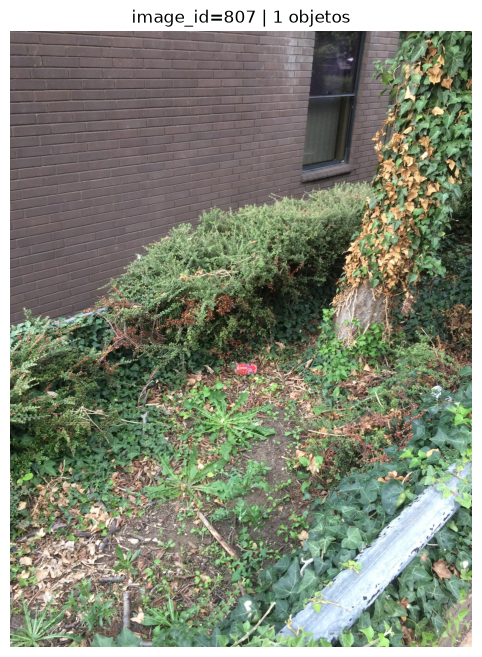

In [6]:
import random

def show_sample_with_masks(image_id, coco, images_dir):
    img_info = next(img for img in coco["images"] if img["id"] == image_id)
    img_path = images_dir / img_info["file_name"]
    if not img_path.exists():
        print(f"Imagen no encontrada en disco: {img_path}")
        return

    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    anns = [a for a in coco["annotations"] if a["image_id"] == image_id]

    overlay = img_rgb.copy()
    for ann in anns:
        for seg in ann.get("segmentation", []):
            if len(seg) < 6:
                continue
            pts = np.array(seg, dtype=np.int32).reshape(-1, 2)
            color = tuple(np.random.randint(0, 255, 3).tolist())
            cv2.fillPoly(overlay, [pts], color)

    blended = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

    plt.figure(figsize=(8, 8))
    plt.imshow(blended)
    plt.title(f"image_id={image_id} | {len(anns)} objetos")
    plt.axis("off")
    plt.show()


images_dir = TACO_DIR
sample_ids = random.sample([img["id"] for img in coco["images"]], k=min(4, len(coco["images"])))
for image_id in sample_ids:
    show_sample_with_masks(image_id, coco, images_dir)


## 6. Conclusiones del EDA (completar tras correr sobre el dataset real)

- Balance de clases: ¿alguna clase macro queda muy por debajo del resto? Si es así,
  evaluar sumar imágenes de Roboflow Universe para esa clase puntual.
- Resolución: ¿conviene fijar `imgsz` de YOLO en 640 o hace falta uno mayor dado el
  tamaño promedio de los objetos pequeños (colillas, tapitas, etc.)?
- Objetos por imagen: confirma que el dataset sí tiene casos de múltiples residuos
  por imagen, respaldando la elección de segmentación de instancias.
